In [6]:
# Base imports
import os
import pickle

# Compute imports
import numpy as np
import pandas as pd
import scipy
from tqdm.notebook import tqdm, trange

# Plotting imports
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px

# ML import
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from pyphylon.util import load_config

In [7]:
# Load in (full) P matrix
df_genes = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results/gene_presence_absence.Rtab', sep = '\t').set_index('Gene')

# Load in (full) metadata
metadata = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/interim/2d_ncbi_enriched_metadata.csv', index_col=0, dtype='object')

In [8]:
# Filter metadata for Complete sequences only
metadata_complete = metadata

# # Filter P matrix for Complete sequences only
df_genes_complete = df_genes
inCompleteseqs = df_genes_complete.sum(axis=1) > 0 # filter for genes found in complete sequences
df_genes_complete = df_genes_complete[inCompleteseqs]

df_genes_complete.shape

(43601, 1317)

In [9]:
# Load in L_binarized matrix
L_binarized = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/L_binarized.csv", index_col=0)
L_binarized

,unchar_1,unchar_2,unchar_3,ST549,China_ST463,unchar_4,unchar_5,unchar_6,ST235,unchar_7,...,unchar_13,unchar_14,unchar_15,unchar_16,unchar_17,unchar_18,ST395,ST621,ST253,unchar_19
Gene,,,,,,,,,,,,,,,,,,,,,
group_35823,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22295,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_14781,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
gatA,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cas1f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_32366,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
group_18075,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


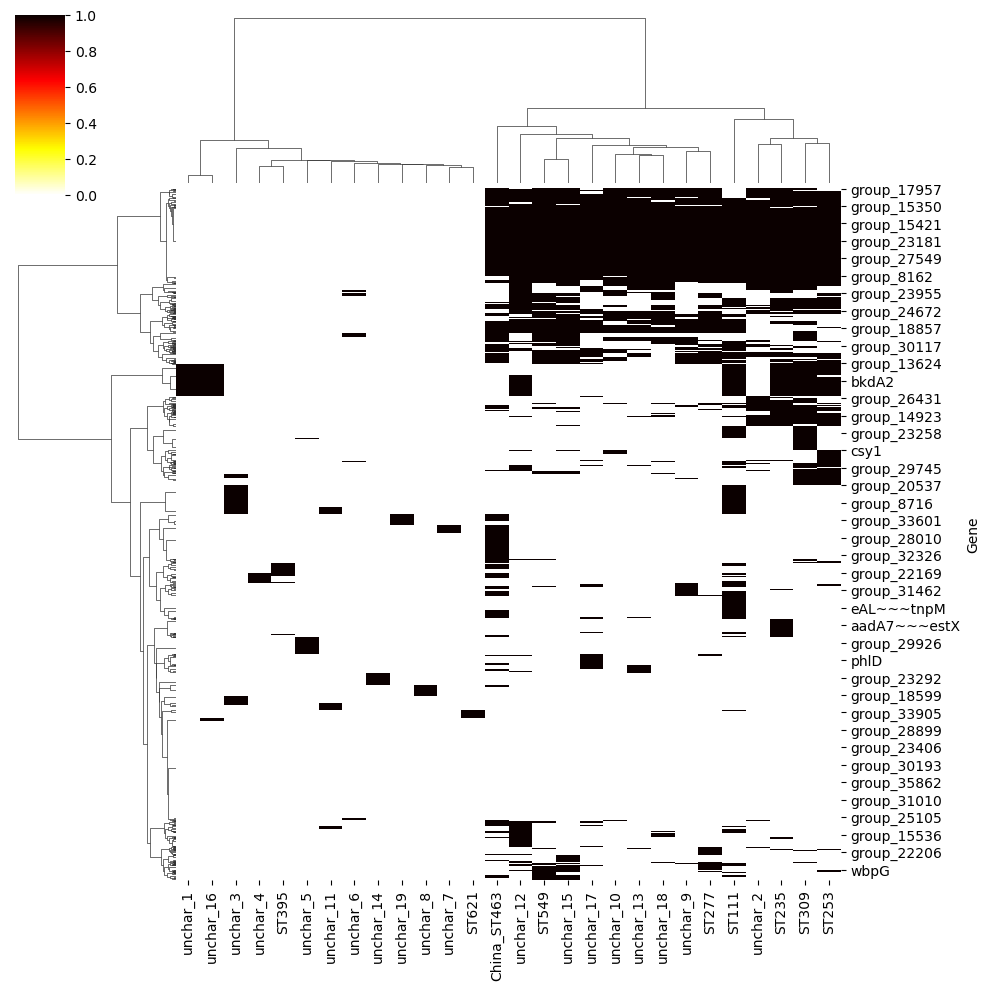

In [10]:
# Grab the clustering order (by Ward's minimum variance)
g = sns.clustermap(
    L_binarized,
    method='ward',
    cmap='hot_r'
);